Epoch 0 Loss 0.4743812680244446
Epoch 500 Loss 1.4298313544713892e-05
Epoch 1000 Loss 5.093328127259156e-06
Epoch 1500 Loss 2.2080128019297263e-06
Epoch 2000 Loss 1.5579696537315613e-06
Epoch 2500 Loss 2.0396653326315572e-06
MSE: 9.213833973946133e-05


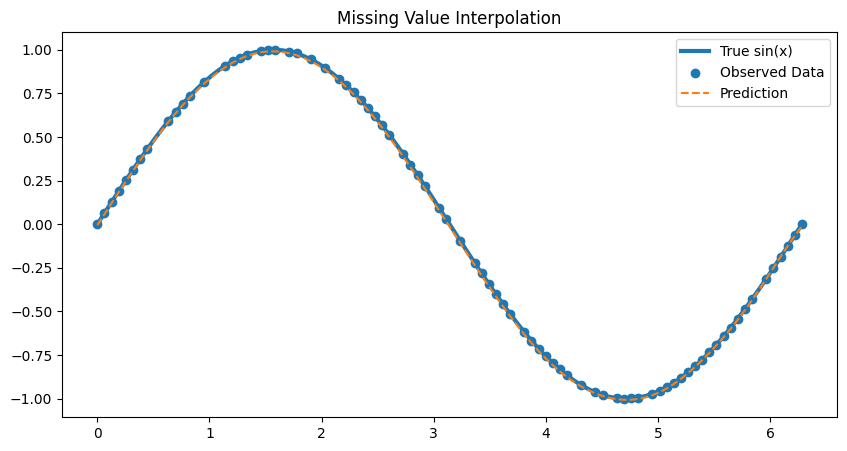

In [ ]:
#欠損値予測２次元グラフ 普通NNver（Neural ODE無し）

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================
# データ生成
# ============================================

x = np.linspace(0, 2*np.pi, 100)

y_true = np.sin(x)

# ============================================
# 欠損作成（null）
# ============================================

y_missing = y_true.copy()

# ランダムに20個欠損
missing_idx = np.random.choice(100, 20, replace=False)

y_missing[missing_idx] = np.nan

# mask作成
mask = ~np.isnan(y_missing)

# ============================================
# Tensor化
# ============================================

x_tensor = torch.tensor(x, dtype=torch.float32).view(-1,1)

y_tensor = torch.tensor(
    np.nan_to_num(y_missing, nan=0.0),
    dtype=torch.float32
).view(-1,1)

mask_tensor = torch.tensor(mask)

# ============================================
# 簡単なNN
# ============================================

model = nn.Sequential(
    nn.Linear(1,64),
    nn.Tanh(),

    nn.Linear(64,64),
    nn.Tanh(),

    nn.Linear(64,1)
)

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(x_tensor)

    # 欠損していない部分だけloss
    loss = criterion(
        pred[mask_tensor],
        y_tensor[mask_tensor]
    )

    loss.backward()

    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} Loss {loss.item()}")

# ============================================
# 推論
# ============================================

with torch.no_grad():
    y_pred = model(x_tensor).numpy()

# ============================================
# MSE計算
# ============================================

mse = np.mean((y_true - y_pred.flatten())**2)

print("MSE:", mse)

# ============================================
# 可視化
# ============================================

plt.figure(figsize=(10,5))

# 真値
plt.plot(x, y_true,
         label='True sin(x)',
         linewidth=3)

# 欠損データ
plt.scatter(
    x[mask],
    y_missing[mask],
    label='Observed Data'
)

# 予測
plt.plot(
    x,
    y_pred,
    '--',
    label='Prediction'
)

plt.legend()

plt.title("Missing Value Interpolation")

plt.show()

Epoch 0
Loss: 17.57669448852539
Epoch 500
Loss: 0.10147134959697723
Epoch 1000
Loss: 0.030756214633584023
Epoch 1500
Loss: 0.003949637524783611
Epoch 2000
Loss: 0.0021195029839873314
Epoch 2500
Loss: 0.0046756332740187645
MSE: 0.002579736259506976


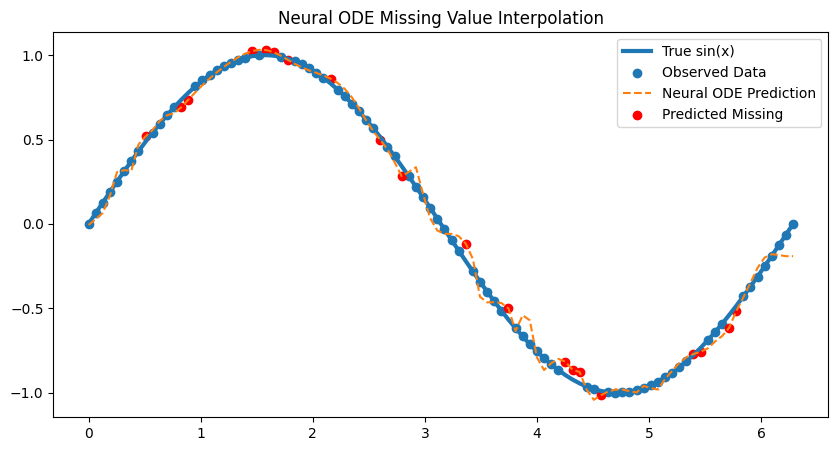

In [2]:
#欠損値予測２次元グラフ Neural ODEver

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# データ生成
# ============================================

x = np.linspace(0, 2*np.pi, 100)

y_true = np.sin(x)

# ============================================
# 欠損作成
# ============================================

y_missing = y_true.copy()

missing_idx = np.random.choice(100, 20, replace=False)

y_missing[missing_idx] = np.nan

mask = ~np.isnan(y_missing)

# ============================================
# Tensor化
# ============================================

x_tensor = torch.tensor(
    x,
    dtype=torch.float32
).view(-1,1)

y_tensor = torch.tensor(
    np.nan_to_num(y_missing, nan=0.0),
    dtype=torch.float32
).view(-1,1)

mask_tensor = torch.tensor(mask)

# ============================================
# ODE Function
# dh/dt = f(h,t)
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,1)
        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE Model
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.odefunc = ODEFunc()

    def forward(self, x_input):

        # 初期値
        h0 = x_input

        # ODE時間
        t = torch.tensor([0,1]).float()

        # ODE solve
        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        # 最終時刻
        return out[-1]

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

# ============================================
# 学習
# ============================================

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(x_tensor)

    loss = criterion(
        pred[mask_tensor],
        y_tensor[mask_tensor]
    )

    loss.backward()

    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}")
        print("Loss:", loss.item())

# ============================================
# 推論
# ============================================

with torch.no_grad():

    y_pred = model(x_tensor).numpy()

# ============================================
# MSE
# ============================================

mse = np.mean(
    (y_true - y_pred.flatten())**2
)

print("MSE:", mse)

# ============================================
# 可視化
# ============================================

plt.figure(figsize=(10,5))

# 真値
plt.plot(
    x,
    y_true,
    label='True sin(x)',
    linewidth=3
)

# 観測点
plt.scatter(
    x[mask],
    y_missing[mask],
    label='Observed Data'
)

# 予測
plt.plot(
    x,
    y_pred,
    '--',
    label='Neural ODE Prediction'
)

# 欠損位置
plt.scatter(
    x[missing_idx],
    y_pred[missing_idx],
    color='red',
    label='Predicted Missing'
)

plt.legend()

plt.title("Neural ODE Missing Value Interpolation")

plt.show()

Epoch 0 Loss 0.6355897784233093
Epoch 200 Loss 0.1828567087650299
Epoch 400 Loss 0.1339738667011261
Epoch 600 Loss 0.10105114430189133
Epoch 800 Loss 0.08250488340854645
Epoch 1000 Loss 0.06763645261526108
Epoch 1200 Loss 0.05560534447431564
Epoch 1400 Loss 0.04933368042111397
Epoch 1600 Loss 0.06488566100597382
Epoch 1800 Loss 0.05068354308605194
MSE: 0.03871597800564898
===== 欠損点予測結果 =====

欠損点 1
予測結果 : (x,y,z)=(-1.31, -1.31, -0.4379)
真値 : (x,y,z)=(-1.31, -1.31, -0.2558)
絶対誤差 : 0.182087
--------------------------
欠損点 2
予測結果 : (x,y,z)=(0.76, -1.31, -0.5207)
真値 : (x,y,z)=(0.76, -1.31, -0.5847)
絶対誤差 : 0.064000
--------------------------
欠損点 3
予測結果 : (x,y,z)=(-0.34, -0.90, 0.2975)
真値 : (x,y,z)=(-0.34, -0.90, 0.2249)
絶対誤差 : 0.072526
--------------------------
欠損点 4
予測結果 : (x,y,z)=(-0.62, -0.62, -0.3219)
真値 : (x,y,z)=(-0.62, -0.62, 0.0381)
絶対誤差 : 0.360010
--------------------------
欠損点 5
予測結果 : (x,y,z)=(1.45, -0.62, -0.7308)
真値 : (x,y,z)=(1.45, -0.62, -0.8176)
絶対誤差 : 0.086742
-------------

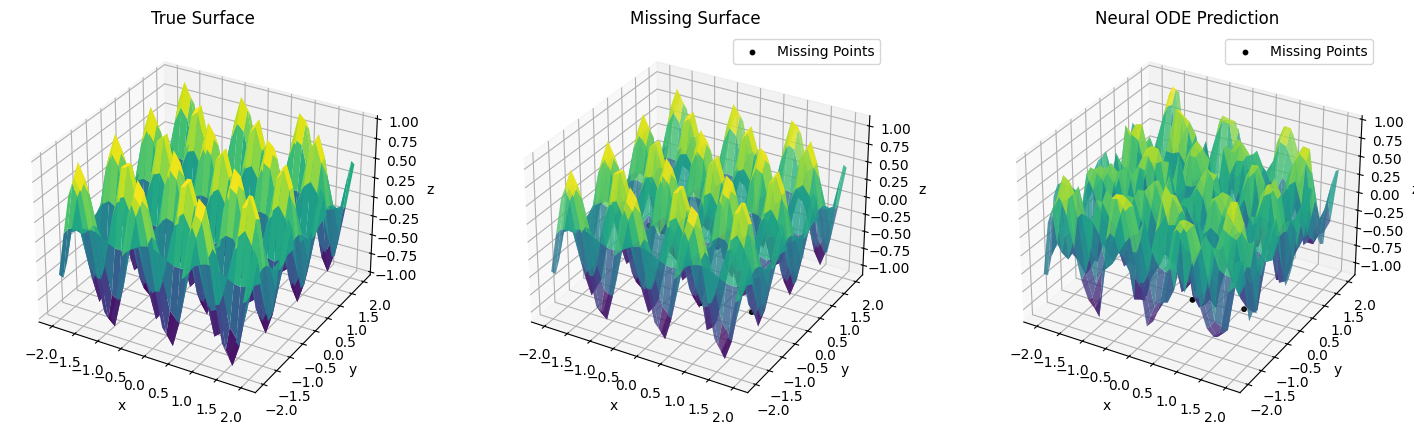

In [53]:
#3次元曲面（z=x^2+y^2）回帰（neural ode ver）

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============================================
# データ生成
# z = x^2 + y^2
# ============================================

grid_size = 30

x = np.linspace(-2, 2, grid_size)
y = np.linspace(-2, 2, grid_size)

X, Y = np.meshgrid(x, y)#x座標とy座標の組み合わせを作るもの。計算やプロットで必要

#Z = X**2 + Y**2
Z= np.sin(5*X) * np.cos(5*Y)

# ============================================
# 欠損値作成
# ============================================

"""
#欠損値ランダム版--------------------------------
Z_missing = Z.copy()

# ランダム欠損
missing_ratio = 0.3

mask = np.random.rand(*Z.shape) > missing_ratio

Z_missing[~mask] = np.nan #欠損値（nan）を代入
#-----------------------------------------------
"""

#欠損値座標指定版--------------------------------
mask = np.ones(Z.shape, dtype=bool)

# 欠損させたい座標(index)
missing_points = [

    (5,5),#この数字は“(x配列のインデックス,y配列のインデックス)”
    (10,10),
    (15,15),
    (20,20),

    (5,20),
    (20,5),

    (8,12),
    (12,8),

    (25,10),
    (10,25)

]

# 指定点を欠損化
for i,j in missing_points:

    mask[i,j] = False

# 欠損入りデータ
Z_missing = Z.copy()

Z_missing[~mask] = np.nan


# ============================================
# 学習データ作成
# ============================================

coords = np.stack(
    [X.flatten(), Y.flatten()], #「データ生成」で作ったmeshgridのデータを一列の座標データのペアを作る（平坦化）
    axis=1
)

targets = Z.flatten()

mask_flat = mask.flatten() #元々の2次元の mask（True=データあり、False=欠損）を、上のリストと同じ順番で1列にします。中身は [True, False, True, ...] のようなチェックリストになる

# 観測点だけ使用
#coords_train: モデルの入力（場所）となる、実測データがある地点だけの座標リスト。
#targets_train: モデルの正解（ラベル）となる、実測データがある地点だけの値リスト。
coords_train = coords[mask_flat]#mask_flatがTrue、つまり「データあり（観測点）」のxy座標だけ抜き出す
targets_train = targets[mask_flat]#同じく欠損値ではないzの値だけ抜き出す

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ============================================
# ODE Function
# ============================================

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,64),#x座標とy座標の二つを入力
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,2)

        )

    def forward(self, t, h):

        return self.net(h)

# ============================================
# Neural ODE Model
# ============================================

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc() #上のODE Functionへ飛んで計算

        # 最終出力
        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        # 初期状態
        h0 = x_input

        # 時間
        t = torch.tensor([0,1]).float() #今回はt(時間)が０～１の間で学習

        # ODE solve
        out = odeint(
            self.odefunc,
            h0,
            t,
            #method='euler'#オイラー法
            method='rk4'#ルンクゲッタ法
        )

        # 最終状態
        h_final = out[-1] #out(出力リスト)の[-1]（一番最後を意味するpythonのインデックス指定）を取り出す

        # z予測
        z_pred = self.output_layer(h_final)

        return z_pred

# ============================================
# モデル
# ============================================

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01 #学習率
)

# ============================================
# 学習
# ============================================

epochs = 2000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)
    
    #誤差計算。criterion＝「基準」の意味。損失関数のことを指す。pred：予測値、targets_tensor：正解データ
    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 200 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ============================================
# 全点予測
# ============================================

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

#torch.no_grad(): 「今は学習ではなく推論（予測）中なので、重みを更新するためのデータ（勾配）は記録しなくていいよ」という指定です。これによりメモリの節約と計算の高速化ができます。
#model(...): モデルに全座標を一気に流し込み、各点の予測値（例えばその地点の高さやクラス確率など）を計算します。
#.numpy(): PyTorchのテンソルを、扱いやすいNumPy配列に戻しています。

with torch.no_grad():

    Z_pred = model(
        all_coords_tensor
    ).numpy()


#モデルに入れるために flatten() で 「1次元の長い列」 になっていた予測結果を、再び 「縦×横（grid_size × grid_size）の行列」 に並べ直しています。
#これにより、2次元グラフの X や Y と形が揃い、描画できるようになる
Z_pred = Z_pred.reshape(
    grid_size,
    grid_size
)

# ============================================
# MSE
# ============================================

mse = np.mean((Z - Z_pred)**2)

print("MSE:", mse)

# 欠損点座標===================================
missing_x = X[~mask]
missing_y = Y[~mask]

# 真値側の欠損点高さ
missing_z= Z[~mask]

# 予測側の欠損点高さ
missing_z_pred = Z_pred[~mask]


# ============================================
# 欠損点精度表示
# ============================================

print("===== 欠損点予測結果 =====\n")

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = missing_z_pred[idx]
    true_val = missing_z[idx]

    error = abs(pred_val - true_val)

    print(f"欠損点 {idx+1}")

    print(
        f"予測結果 : "
        f"(x,y,z)=("
        f"{x_val:.2f}, "
        f"{y_val:.2f}, "
        f"{pred_val:.4f})"
    )

    print(
        f"真値 : "
        f"(x,y,z)=("
        f"{x_val:.2f}, "
        f"{y_val:.2f}, "
        f"{true_val:.4f})"
    )

    print(
        f"絶対誤差 : {error:.6f}"
    )

    print("--------------------------")

# ============================================
# 欠損点MSE
# ============================================

missing_mse = np.mean(
    (missing_z - missing_z_pred)**2
)

print("\n===================================")
print("欠損点MSE :", missing_mse)
print("===================================\n")


# ============================================
# 可視化
# ============================================

fig = plt.figure(figsize=(18,5))

# 真値
ax1 = fig.add_subplot(131, projection='3d')

ax1.plot_surface(
    X, Y, Z,
    cmap='viridis'
)
"""
# 欠損点を赤表示
ax1.scatter(
    missing_x,
    missing_y,
    missing_z,
    color='black',
    s=10,
    label='Missing Points'
)
ax1.legend()
"""

ax1.set_title("True Surface")
ax1.set_xlabel('x') # x軸のラベル
ax1.set_ylabel('y') # y軸のラベル
ax1.set_zlabel('z') # z軸のラベル

# 欠損あり
ax2 = fig.add_subplot(132, projection='3d')

ax2.plot_surface(
    X,
    Y,
    np.nan_to_num(Z_missing, nan=0),
    cmap='viridis', #cmap(color map):色の付け方の指定,viridis は matplotlib 標準のカラーマップです。
    alpha=0.8 #透明度
)

#欠損店を赤色で表示------


ax2.scatter(
    missing_x,
    missing_y,
    missing_z,
    color='black',
    s=10,
    label='Missing Points'
)

ax2.legend()
ax2.set_title("Missing Surface")
ax2.set_xlabel('x') # x軸のラベル
ax2.set_ylabel('y') # y軸のラベル
ax2.set_zlabel('z') # z軸のラベル

# 予測
ax3 = fig.add_subplot(133, projection='3d')

ax3.plot_surface(
    X,
    Y,
    Z_pred,
    cmap='viridis',
    alpha=0.8 #透明度
)
# 欠損点を赤表示
ax3.scatter(
    missing_x,
    missing_y,
    missing_z,
    color='black',
    s=10,
    label='Missing Points'
)

ax3.legend()

ax3.legend()
ax3.set_title("Neural ODE Prediction")
ax3.set_xlabel('x') # x軸のラベル
ax3.set_ylabel('y') # y軸のラベル
ax3.set_zlabel('z') # z軸のラベル

plt.show()
import plotly.graph_objects as go
# 真の関数グラフ
true_fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale='Greens',
            contours = {
            "x": {"show": True},
            "y": {"show": True}
        }
      )
    ]
)
true_fig.update_layout(
    title='True Surface', # タイトルのテキスト
    title_x=0.5,               # タイトルを中央に配置（0が左、1が右）
    scene=dict(
        aspectmode='cube' #xyz軸の長さを均等に
    )
)
true_fig.show()


# neural ode予測結果
pred_fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z_pred,
            colorscale='Greens',
            contours = {
            "x": {"show": True},
            "y": {"show": True}
        }
      )
    ]
)
# 欠損点を赤表示
pred_fig.add_trace(
    go.Scatter3d(
        x=missing_x,
        y=missing_y,
        z=missing_z,

        mode='markers',

        marker=dict(
            size=1,
            color='black'
        ),

        name='Missing Points'
    )
)

pred_fig.update_layout(
    title='Neural ODE Prediction', # タイトルのテキスト
    title_x=0.5,               # タイトルを中央に配置（0が左、1が右）
    scene=dict(
        aspectmode='cube' #xyz軸の長さを均等に
    )
)

pred_fig.show()